# ML Pipeline Extended: Przewidywanie Zużycia Paliwa (MPG)

W tej wersji rozszerzonej wprowadzamy profesjonalne wzorce inżynieryjne:
*   **Sklearn Pipeline & ColumnTransformer** - aby uniknąć Data Leakage i zapewnić czysty kod.
*   **One-Hot Encoding (OHE)** - realizowany przez transformator scikit-learn.
*   **Grid Search** - automatyczna optymalizacja hiperparametrów.
*   **Serialization** - zapis i odczyt modelu do pliku.
*   **SHAP** - wyjaśnialność modelu (Explainable AI).

## Przygotowanie Danych

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

# Załadowanie danych
df = sns.load_dataset('mpg').dropna()
print(f"Załadowano {len(df)} rekordów.")
df.head()

Załadowano 392 rekordów.


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


## Inżynieria Cech

In [2]:
# Cecha 1: Moc na wagę (Power-to-weight ratio)
df['hp_per_weight'] = df['horsepower'] / df['weight']

# Cecha 2: Wiek
reference_year = df['model_year'].max()
df['car_age'] = reference_year - df['model_year']

features_num = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'hp_per_weight', 'car_age']
features_cat = ['origin']
target = 'mpg'

X = df[features_num + features_cat].copy()
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Rozmiar treningowy: {X_train.shape}")

Rozmiar treningowy: (313, 8)


## Demo: Jak działa OneHotEncoder?
Zanim wrzucimy OHE do Pipeline'u, zobaczmy jak działa „pod maską” w porównaniu do prostego `get_dummies`.

In [3]:
from sklearn.preprocessing import OneHotEncoder

demo_ohe = OneHotEncoder(sparse_output=False)
sample_data = X_train[['origin']].head(10)

# 1. Fit - encoder uczy się unikalnych kategorii (tworzy słownik)
demo_ohe.fit(sample_data)
print(f"Wykryte kategorie: {demo_ohe.categories_}")

# 2. Transform - zamiana na macierz binarną
encoded = demo_ohe.transform(sample_data)
encoded_df = pd.DataFrame(encoded, columns=demo_ohe.get_feature_names_out(['origin']))
pd.concat([sample_data.reset_index(drop=True), encoded_df], axis=1)

Wykryte kategorie: [array(['europe', 'usa'], dtype=object)]


,origin,origin_europe,origin_usa
0,usa,0.0,1.0
1,usa,0.0,1.0
2,usa,0.0,1.0
3,usa,0.0,1.0
4,usa,0.0,1.0
5,usa,0.0,1.0
6,europe,1.0,0.0
7,usa,0.0,1.0
8,usa,0.0,1.0
9,usa,0.0,1.0


## Sklearn Pipeline & ColumnTransformer

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

# Definicja preprocessora (Separation of Concerns)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_num),
        ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat)
    ])

# Pełny Pipeline (Preprocessing + Model)
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(objective='reg:squarederror', random_state=42))
])

model_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

## Optymalizacja Modelu (Grid Search)

In [5]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'regressor__n_estimators': [50, 75, 100],
    'regressor__max_depth': [3, 5],
    'regressor__learning_rate': [0.1, 0.2]
}

grid_search = GridSearchCV(model_pipeline, param_grid, cv=5, 
                           scoring='neg_mean_absolute_error', 
                           n_jobs=-1, verbose=1)

print("Uruchamiam Grid Search...")
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

Uruchamiam Grid Search...
Fitting 5 folds for each of 12 candidates, totalling 60 fits


## Serializacja i Wczytywanie Modelu

In [6]:
import datetime
import joblib

# Tworzenie unikalnej nazwy pliku
timestamp = datetime.datetime.now().strftime("%Y_%m_%d_%H_%M")
model_filename = f"DS_Pipeline_MPG_Extended_{timestamp}.joblib"

print(f"Zapisuję model do: {model_filename}")
joblib.dump(best_model, model_filename)

# Wczytywanie modelu z powrotem
print("Wczytuję model z pliku do walidacji...")
loaded_pipeline = joblib.load(model_filename)

Zapisuję model do: DS_Pipeline_MPG_Extended_2026_03_25_21_26.joblib
Wczytuję model z pliku do walidacji...


## Ewaluacja (Train vs Test)
Porównanie wyników na obu zbiorach pozwala wykryć Overfitting.

In [7]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

def get_metrics(model, X, y, label):
    preds = model.predict(X)
    mae = mean_absolute_error(y, preds)
    mape = mean_absolute_percentage_error(y, preds)
    r2 = r2_score(y, preds)
    print(f"--- Metryki dla: {label} ---")
    print(f"MAE: {mae:.2f} mpg")
    print(f"MAPE: {mape:.2%}")
    print(f"R2 Score: {r2:.2f}\n")

get_metrics(loaded_pipeline, X_train, y_train, "Zbiór Treningowy")
get_metrics(loaded_pipeline, X_test, y_test, "Zbiór Testowy")

--- Metryki dla: Zbiór Treningowy ---
MAE: 1.09 mpg
MAPE: 4.84%
R2 Score: 0.97

--- Metryki dla: Zbiór Testowy ---
MAE: 1.75 mpg
MAPE: 8.01%
R2 Score: 0.88



## Wyjaśnialność (SHAP)
Zrozummy, dlaczego model podejmuje takie, a nie inne decyzje.

In [8]:
import shap
import matplotlib.pyplot as plt

# Ekstrakcja danych przetworzonych z Pipeline
X_train_transformed = loaded_pipeline.named_steps['preprocessor'].transform(X_train)
ohe_features = loaded_pipeline.named_steps['preprocessor']\
               .named_transformers_['cat']\
               .get_feature_names_out(features_cat)
all_feature_names = features_num + list(ohe_features)
X_train_df = pd.DataFrame(X_train_transformed, columns=all_feature_names)

# Inicjalizacja SHAP
explainer = shap.Explainer(loaded_pipeline.named_steps['regressor'])
shap_values = explainer(X_train_df)

### Globalna Istotność Cech (Summary Plot)

**Jak interpretować:**
*   **Pozycja na osi Y:** Cechy od najważniejszych (góra) do najmniej istotnych.
*   **Kolor kropki:** Wartość cechy (Czerwony = Wysoka, Niebieski = Niska).
*   **Oś X (SHAP value):** Wpływ na wynik. Przesunięcie w lewo obniża predykcję MPG, w prawo podwyższa.

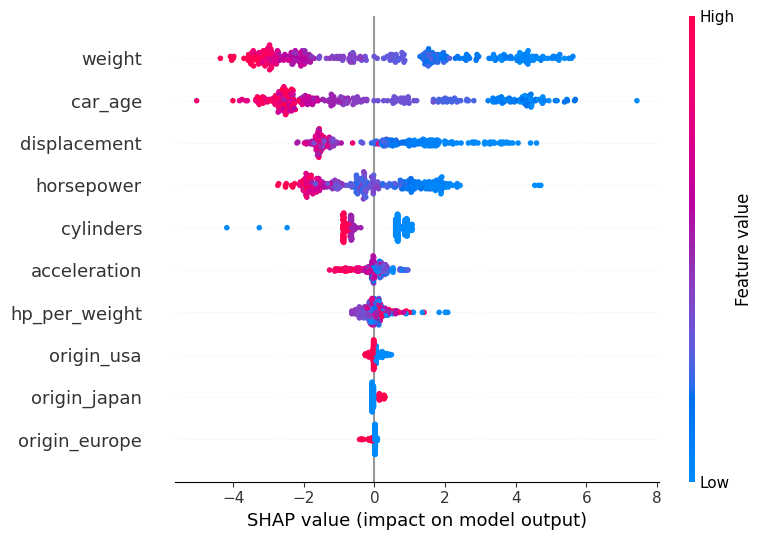

In [9]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train_df)

### Force plot
Przeciąganie liny  między dwiema drużynami cech.

- Base Value (Punkt startowy): To jest średnia predykcja dla całego datasety.
- Kolor Czerwony (Popychają w prawo)
- Kolor Niebieski (Ciągną w lewo):

In [10]:
shap.initjs()
explanation = explainer(X_train_df)
shap.plots.force(explanation[0])